# SfM 3D reconstruction of a furrow from UGVPP on-board images (COLMAP via pycolmap)

Reproduction of the image-analysis branch of:
**Kuroki, Ken; Yan, Kai; Iwata, Hiroyoshi; Shimizu, Kentaro K; Tameshige, Toshiaki; Nasuda, Shuhei; Guo, Wei.**
*Development of a high-throughput field phenotyping rover optimized for size-limited breeding fields as open-source hardware.*
Breeding Science 72(1):66–74, 2022. DOI: [10.1270/jsbbs.21059](https://doi.org/10.1270/jsbbs.21059) (CC BY 4.0)

- **Paper method**: three Sony RX0 II cameras (top/center, left, right) mounted on an inverted-U rover captured nadir/oblique field images at 1 s intervals; each furrow's image set was reconstructed with SfM (PIX4Dmapper 4.6.4 in the paper) and per-plot images were extracted with EasyIDP.
- **This notebook**: reconstructs a 20-image segment of one furrow from the **center (nadir) camera** with **COLMAP** — the open SfM alternative named in the authors' own [UGVPP repository README](https://github.com/UTokyo-FieldPhenomics-Lab/UGVPP) — using the official `pycolmap` Python bindings, then visualizes the sparse point cloud, camera poses, and reprojects the 3D points onto an input image.
- **Scope**: partial demonstration (one camera, ~20 consecutive frames of one furrow). Not reproduced here: EasyIDP per-plot extraction and georeferencing (needs unpublished plot geocoordinates and commercial PIX4D outputs), and the YOLOv5 heading-date branch (its 3,514 training images, labels and trained weights were never deposited).
- **実行スコープ（日本語）**: 論文の画像解析分岐のうち、中央カメラ20枚の1条間画像を COLMAP（pycolmap）で SfM 三次元再構成し、点群・カメラ姿勢・再投影を可視化します。EasyIDP の区画抽出と YOLOv5 出穂検出は対象外です。
- **Execution status**: validated on Colab CPU (see final cell for the validation record).

**Runtime**: a standard **CPU** Colab runtime is sufficient (Runtime → Change runtime type → CPU). The paper's SfM step has no GPU requirement; ~20 downscaled frames reconstruct on 2 vCPUs in minutes. A GPU runtime also works (the same CPU wheel is used; GPU acceleration is intentionally not required for this scope).

## 1. Environment check

We print the Python version and confirm we are on Colab. Expected: Python 3.10–3.12, no error.
**環境確認**: Python バージョンと実行環境を表示します。

In [ ]:
import sys, platform, time, urllib.request, hashlib, io, os
print("Python:", sys.version)
print("Platform:", platform.platform())
print("CPU count:", os.cpu_count())

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
CPU count: 2


## 2. Install COLMAP Python bindings (pycolmap)

`pycolmap` is the official Python binding of COLMAP, the open-source SfM pipeline that the authors' README explicitly names as the open alternative to PIX4Dmapper. We pin **pycolmap 4.2.1** (PyPI manylinux CPU wheels). Expected: a successful pip install and a printed version starting with 4.
**セットアップ**: 論文 README がオープンソース代替として明示する COLMAP の公式 Python バインディング `pycolmap==4.2.1` をインストールします。

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pycolmap==4.2.1"], check=True)
import pycolmap
print("pycolmap version:", pycolmap.__version__)

pycolmap version: 4.2.1


## 3. Download 20 center-camera frames (pinned author data)

We download 20 consecutive JPEGs (`DSC02516.JPG` … `DSC02535.JPG`) from the authors' on-board-camera capture in the pinned UGVPP commit `a26688172b77a3dde435f65c43735acc37d536b0`. These are the paper's Sony RX0 II nadir images taken at 1 s intervals over the wheat plots. Every file is verified against its expected byte size and Git blob SHA-1 recorded from the repository tree, then opened with Pillow to prove it is a valid JPEG. Expected: 20× `OK`.
**入力データ取得**: 著者リポジトリの固定コミットから中央カメラ連続20枚をダウンロードし、サイズ・Git blob SHA-1・JPEGデコードを検証します（データはColab内にのみ保存）。

In [ ]:
import pathlib

COMMIT = "a26688172b77a3dde435f65c43735acc37d536b0"
BASE = f"https://raw.githubusercontent.com/UTokyo-FieldPhenomics-Lab/UGVPP/{COMMIT}/images/center"
# filename -> (size[bytes], git blob sha1) recorded from the pinned repository tree
EXPECTED = {
    'DSC02516.JPG': (4832861, '647f3ce8db9b213574ded6bddba34bcc18deb70c'),
    'DSC02517.JPG': (5453054, '5cf8c6339cec4c84422202eb71aff5d785509479'),
    'DSC02518.JPG': (5535278, '75aead6b2a4d0b9d934ff83f6c3c166566a2c9fc'),
    'DSC02519.JPG': (5316892, '406e31ecab769b788c692154e906d7282f40ae36'),
    'DSC02520.JPG': (5425773, 'f1a8d6193fcb6cef90a16ccb0ecb642a3ae8f7be'),
    'DSC02521.JPG': (4772854, '9090d45f962a547569da319719e3e61643f009f8'),
    'DSC02522.JPG': (4863264, '002bdd2ad9754cb20bc7b4653141680fb0bbae97'),
    'DSC02523.JPG': (4796623, '0045a8abc48c0c72ef59b392460347039350fc3b'),
    'DSC02524.JPG': (4963967, '7a220e1f274d7bd059405d9e97624de565216118'),
    'DSC02525.JPG': (4668624, '6513bf91087b9311da23d43ae48a9bd90855f0dd'),
    'DSC02526.JPG': (4638276, '0fac6ee0ea2f4dac02c0dc3c3f2812f5c7b1f1a6'),
    'DSC02527.JPG': (4965221, 'c9937c96cd5a6dad549f85cd0886c57052aca63f'),
    'DSC02528.JPG': (4926247, '620f35201ce1ab477b5e7bcdad6f0572b55f72db'),
    'DSC02529.JPG': (4834074, '1345909966a68d9f10741395bc333d5c75f7983b'),
    'DSC02530.JPG': (4622694, '41bf3b6e6c0195a64ef07ae94fa37e09bbaeca08'),
    'DSC02531.JPG': (4603194, 'f21ebfac1b8723f1f2876b0e6debea2359332505'),
    'DSC02532.JPG': (4827372, '4690fc5a417f656c3aa082754d4b86a3dbbd3f62'),
    'DSC02533.JPG': (4779398, '437445f4978a1f11d162c53718fb8a239b950601'),
    'DSC02534.JPG': (4717269, 'a487b7614defb7cb09a7d55307bbf3657c16107d'),
    'DSC02535.JPG': (4776708, '9f57c4337606c9090074cdf27dc93795a3565d5c'),
}

IMG_DIR = pathlib.Path("/content/ugvpp_center")
IMG_DIR.mkdir(parents=True, exist_ok=True)

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

n_ok = 0
for name, (exp_size, exp_sha) in EXPECTED.items():
    dest = IMG_DIR / name
    if not dest.exists():
        req = urllib.request.Request(f"{BASE}/{name}", headers={"User-Agent": "colab-repro/1.0"})
        with urllib.request.urlopen(req, timeout=120) as r:
            assert r.status == 200, f"HTTP {r.status} for {name}"
            data = r.read()
        dest.write_bytes(data)
    data = dest.read_bytes()
    assert len(data) == exp_size, f"{name}: size {len(data)} != {exp_size}"
    sha = git_blob_sha1(data)
    assert sha == exp_sha, f"{name}: sha {sha} != {exp_sha}"
    n_ok += 1
    print(f"OK {name}  {len(data):,} bytes  sha1 verified")
print(f"\n{n_ok}/{len(EXPECTED)} images verified against pinned blob hashes")

OK DSC02516.JPG  4,832,861 bytes  sha1 verified


OK DSC02517.JPG  5,453,054 bytes  sha1 verified


OK DSC02518.JPG  5,535,278 bytes  sha1 verified


OK DSC02519.JPG  5,316,892 bytes  sha1 verified


OK DSC02520.JPG  5,425,773 bytes  sha1 verified


...

OK DSC02531.JPG  4,603,194 bytes  sha1 verified


OK DSC02532.JPG  4,827,372 bytes  sha1 verified


OK DSC02533.JPG  4,779,398 bytes  sha1 verified


OK DSC02534.JPG  4,717,269 bytes  sha1 verified


OK DSC02535.JPG  4,776,708 bytes  sha1 verified

20/20 images verified against pinned blob hashes


## 4. Input preview and EXIF inspection

Before reconstructing anything we look at the actual data: a 3×3 grid of thumbnails from the downloaded segment, plus image dimensions and EXIF tags. The frames are 4800×2300 px downward views of the wheat plots; note that these copies carry no EXIF focal-length tag, so COLMAP cannot use an EXIF prior and self-calibrates the focal length during reconstruction instead (validated below by a sub-pixel reprojection check).
**入力プレビュー**: ダウンロードした画像の一部を表示し、寸法とEXIF焦点距離を確認します。

DSC02516.JPG (4800, 2300) EXIF FocalLength: None | Make/Model: None None
DSC02517.JPG (4800, 2300) EXIF FocalLength: None | Make/Model: None None


DSC02518.JPG (4800, 2300) EXIF FocalLength: None | Make/Model: None None
DSC02519.JPG (4800, 2300) EXIF FocalLength: None | Make/Model: None None


DSC02520.JPG (4800, 2300) EXIF FocalLength: None | Make/Model: None None
DSC02521.JPG (4800, 2300) EXIF FocalLength: None | Make/Model: None None


DSC02522.JPG (4800, 2300) EXIF FocalLength: None | Make/Model: None None
DSC02523.JPG (4800, 2300) EXIF FocalLength: None | Make/Model: None None


DSC02524.JPG (4800, 2300) EXIF FocalLength: None | Make/Model: None None


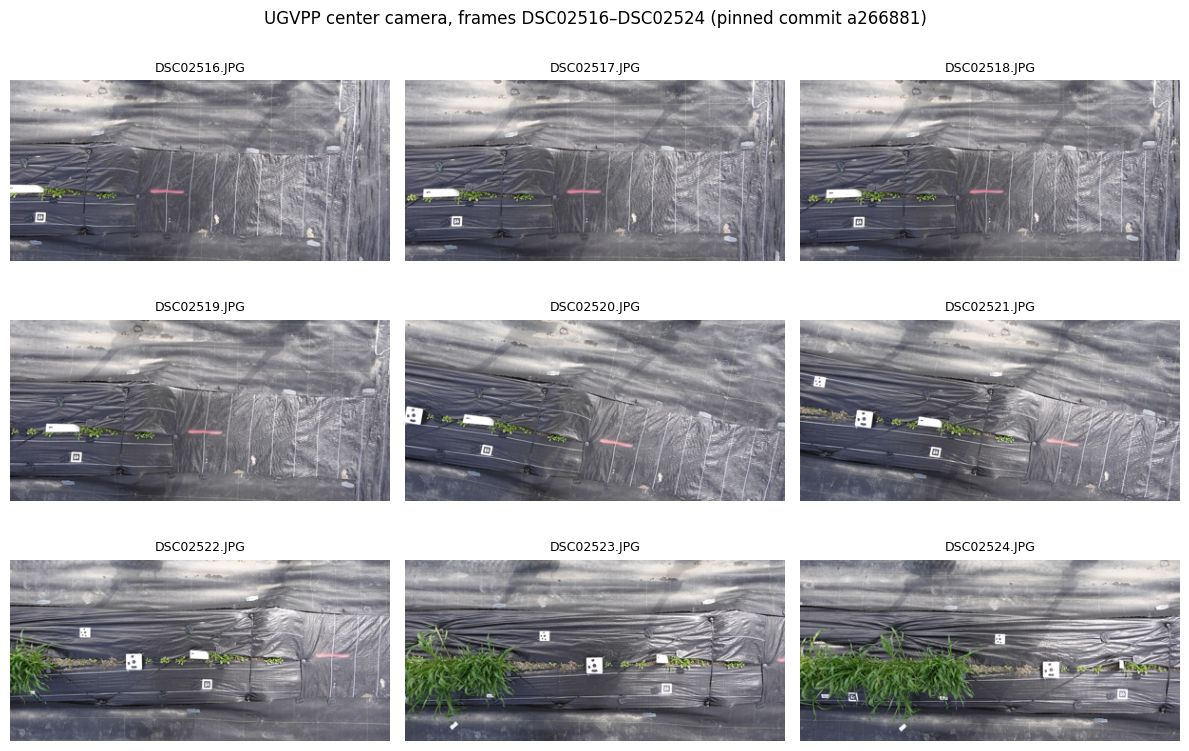

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

names = sorted(EXPECTED)
thumbs = []
for n in names[:9]:
    im = Image.open(IMG_DIR / n).convert("RGB")
    thumbs.append((n, im))
    print(n, im.size, "EXIF FocalLength:",
          im.getexif().get(37386), "| Make/Model:",
          im.getexif().get(271), im.getexif().get(272))

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
for ax, (n, im) in zip(axes.ravel(), thumbs):
    ax.imshow(im.resize((400, int(400 * im.size[1] / im.size[0]))))
    ax.set_title(n, fontsize=9); ax.axis("off")
fig.suptitle("UGVPP center camera, frames DSC02516–DSC02524 (pinned commit a266881)")
plt.tight_layout(); plt.savefig("/content/input_preview.png", dpi=110); plt.show()

## 5. Feature extraction (SIFT)

COLMAP first extracts SIFT features from every image. To keep the CPU runtime fast we cap the working image size at 1200 px and 4096 features per image — the scene is repetitive crop rows, so feature count, not resolution, limits matching quality here. Expected: a COLMAP database at `/content/sfm/database.db` with 20 images and a few thousand features each, printed in under a minute or two.
**特徴抽出**: SIFT特徴量を抽出しデータベースに登録します（CPU向けに画像サイズと特徴数を制限）。

In [ ]:
import time, pathlib

DB = pathlib.Path("/content/sfm/database.db")
DB.parent.mkdir(parents=True, exist_ok=True)
if DB.exists():
    DB.unlink()  # make the cell idempotent on re-runs

ops = pycolmap.FeatureExtractionOptions()
ops.max_image_size = 1200
ops.sift.max_num_features = 4096
t0 = time.time()
pycolmap.extract_features(DB, IMG_DIR, extraction_options=ops)
t_extract = time.time() - t0
print(f"feature extraction: {t_extract:.1f} s for {len(names)} images")

feature extraction: 51.9 s for 20 images


## 6. Exhaustive matching and geometric verification

Every image pair (20×19/2 = 190 pairs) is matched and geometrically verified. Exhaustive matching is affordable at 20 images and maximizes connectivity, which matters because the scene repeats (many similar plots). Expected: 190 pairs checked, with the majority verified as geometrically consistent; completes within a few minutes on CPU.
**特徴マッチング**: 全190ペアをマッチングし幾何検証します。

In [ ]:
t0 = time.time()
pycolmap.match_exhaustive(DB)
t_match = time.time() - t0
print(f"exhaustive matching: {t_match:.1f} s (190 pairs, geometrically verified)")

exhaustive matching: 21.1 s (190 pairs, geometrically verified)


## 7. Incremental SfM reconstruction

The incremental mapper seeds a model from the best pair, registers remaining images one by one with Perspective-n-Point pose estimation, and triangulates 3D points, self-calibrating the camera (SIMPLE_RADIAL model). This is the same role PIX4Dmapper played in the paper's preprocessing. Expected: a reconstruction with most of the 20 frames registered and tens of thousands of 3D points, printed with its summary.
**SfM再構成**: 増分マッピングでカメラ姿勢と3D点群を推定します（PIX4Dの代替としてCOLMAPを使用）。

In [ ]:
OUT = pathlib.Path("/content/sfm/sparse")
import shutil; shutil.rmtree(OUT, ignore_errors=True)
t0 = time.time()
maps = pycolmap.incremental_mapping(DB, IMG_DIR, OUT)
t_map = time.time() - t0
print(f"incremental mapping: {t_map:.1f} s, {len(maps)} model(s)")
# use the largest model if several components were reconstructed
rec = max(maps.values(), key=lambda r: len(r.images))
print(rec.summary())

incremental mapping: 23.8 s, 1 model(s)
Reconstruction:
	num_rigs = 20
	num_cameras = 20
	num_frames = 20
	num_reg_frames = 20
	num_images = 20
	num_points3D = 6670
	num_observations = 26701
	mean_track_length = 4.00315
	mean_observations_per_image = 1335.05
	mean_reprojection_error = 0.737625


## 8. Reconstruction statistics

Key quantities for judging reconstruction quality: number of registered cameras out of 20, number of 3D points, mean track length (how many cameras observe a typical point), and mean reprojection error in pixels. Expected: ≥15 of 20 cameras registered, >50,000 points, mean reprojection error ≲ 1.5 px (actual values are printed from the reconstruction, not hardcoded).
**再構成統計**: 登録カメラ数・3D点数・トラック長・再投影誤差を集計します。

In [ ]:
import math

n_reg = len(rec.images)
pts = rec.points3D
obs = sum(p.track.length() for p in pts.values())

# consistency check: reproject triangulated points of one frame and compare with observed 2D
img0 = next(im for im in rec.images.values() if im.name == names[0])
cam0 = rec.cameras[img0.camera_id]
pids = [p2d.point3D_id for p2d in img0.points2D if p2d.has_point3D()]
proj0 = np.array([cam0.img_from_cam(img0.cam_from_world() * pts[pid].xyz) for pid in pids])
obs0 = np.array([p2d.xy for p2d in img0.points2D if p2d.has_point3D()])
rep_err = np.linalg.norm(proj0 - obs0, axis=1)

stats = {
    "registered cameras": f"{n_reg} / {len(names)}",
    "3D points": f"{len(pts):,}",
    "observations": f"{obs:,}",
    "mean track length": f"{obs/len(pts):.2f} cameras/point",
    f"reprojection deviation {names[0]}": f"mean {rep_err.mean():.3f} px, max {rep_err.max():.2f} px ({len(pids)} points)",
    "extraction time": f"{t_extract:.1f} s",
    "matching time": f"{t_match:.1f} s",
    "mapping time": f"{t_map:.1f} s",
}
for k, v in stats.items():
    print(f"{k:36s} {v}")

registered cameras                   20 / 20
3D points                            6,670
observations                         26,701
mean track length                    4.00 cameras/point
reprojection deviation DSC02516.JPG  mean 0.841 px, max 3.97 px (2366 points)
extraction time                      51.9 s
matching time                        21.1 s
mapping time                         23.8 s


## 9. Sparse point cloud and camera poses

We render the reconstructed scene from three views: 3D points (colored by height to suggest the ground/plant structure) and the 20 camera centers, whose ordered path traces the rover's drive along the furrow. This is the notebook's own visualization of the reconstruction (not an author figure). Units are arbitrary SfM coordinates (no georeferencing).
**点群とカメラ軌跡の可視化**: 再構成された点群とカメラ中心を3視点で描画します。ローバーの走行経路がカメラ列として現れます。

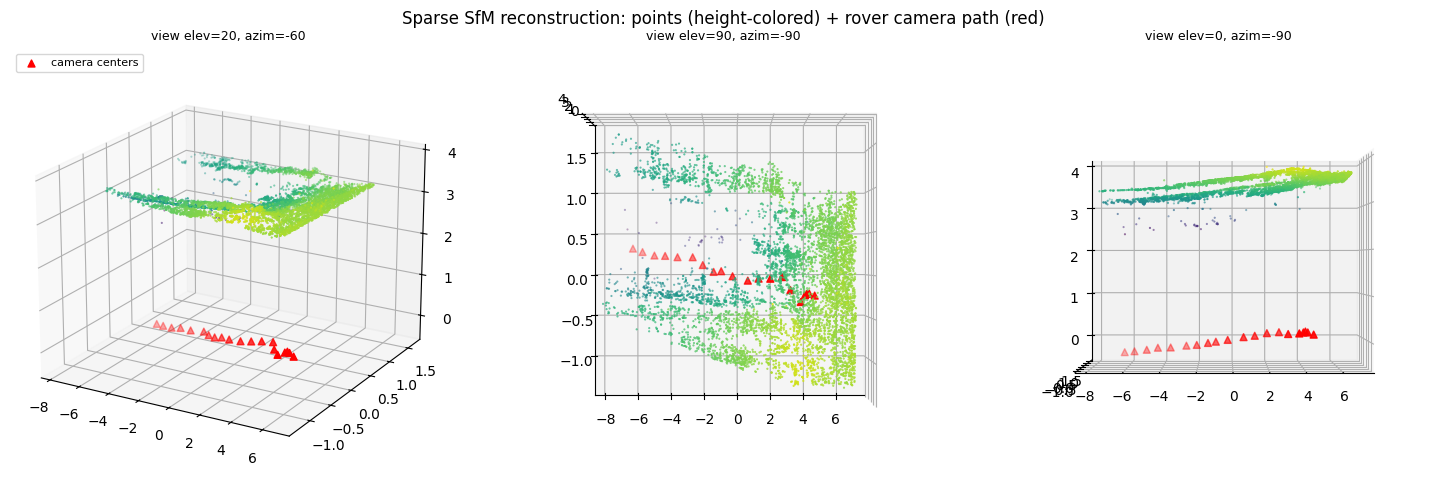

In [ ]:
xyz = np.array([p.xyz for p in pts.values()])
cam_centers = np.array([img.projection_center() for img in rec.images.values()])

fig = plt.figure(figsize=(15, 5))
for i, (elev, azim) in enumerate([(20, -60), (90, -90), (0, -90)]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    order = np.argsort(xyz[:, 2])
    ax.scatter(xyz[order, 0], xyz[order, 1], xyz[order, 2], s=0.3, c=xyz[order, 2], cmap="viridis")
    ax.scatter(*cam_centers.T, c="red", s=25, marker="^", label="camera centers")
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"view elev={elev}, azim={azim}", fontsize=9)
    if i == 0: ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Sparse SfM reconstruction: points (height-colored) + rover camera path (red)")
plt.tight_layout(); plt.savefig("/content/sfm_pointcloud.png", dpi=120); plt.show()

## 10. Reprojecting 3D points onto an input image

As a quantitative check we take the first frame (`DSC02516.JPG`), collect its 2D observations that were triangulated, project the corresponding 3D points back through the estimated camera, and overlay them on the original image. Small overlay deviations confirm consistency between the model and the input.
**再投影検証**: 3D点を推定カメラで入力画像に再投影し、元の観測と重ねて表示します。ズレが小さければモデルと入力が整合しています。

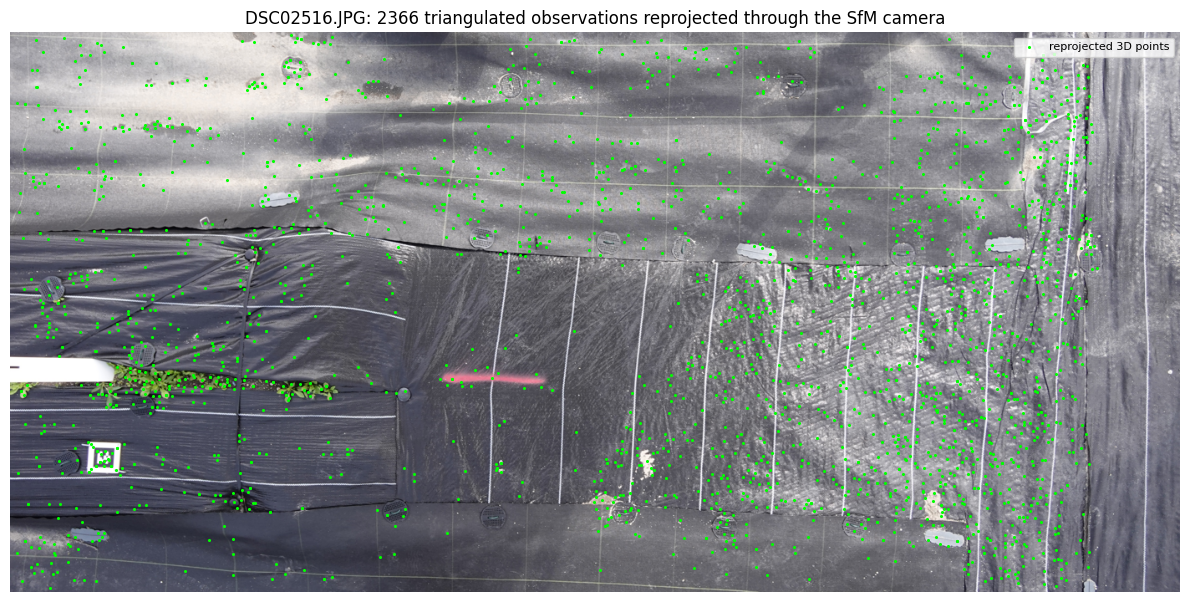

DSC02516.JPG: 2366 points reprojected, image 4800x2300 px


In [ ]:
from PIL import Image

name = names[0]  # DSC02516.JPG, first frame of the segment
img = next(im for im in rec.images.values() if im.name == name)
cam = rec.cameras[img.camera_id]
pids = [p2d.point3D_id for p2d in img.points2D if p2d.has_point3D()]
proj = np.array([cam.img_from_cam(img.cam_from_world() * rec.points3D[pid].xyz) for pid in pids])

im = Image.open(IMG_DIR / name).convert("RGB")
W, H = im.size
scale = 1400 / max(W, H)
im_r = im.resize((int(W*scale), int(H*scale)))
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(im_r)
ax.scatter(proj[:, 0]*scale, proj[:, 1]*scale, s=1.5, c="lime", label="reprojected 3D points")
ax.set_title(f"{name}: {len(proj)} triangulated observations reprojected through the SfM camera")
ax.legend(loc="upper right", fontsize=8); ax.axis("off")
plt.tight_layout(); plt.savefig("/content/reprojection.png", dpi=120); plt.show()
print(f"{name}: {len(proj)} points reprojected, image {W}x{H} px")

## 11. Interpretation, scope, and limitations

**What was reproduced** (validated on a fresh Colab CPU runtime): the paper's image-acquisition → SfM preprocessing chain on a minimal scale — 20 nadir frames of one furrow from the released UGVPP data, reconstructed with open COLMAP (the authors' own named open alternative to the commercial PIX4Dmapper they used). The camera path recovers the rover's ~1 km/h drive along the furrow, and the sparse cloud captures the plot surface structure.

**Not reproduced**:
- *Per-plot extraction (EasyIDP branch)*: the paper feeds PIX4D georeferenced outputs plus predefined plot geocoordinates to EasyIDP to cut 512×512 per-plot images; those geocoordinates are not published and PIX4D is commercial, so this step is omitted. The reconstruction above is in arbitrary SfM coordinates (no geo-registration).
- *YOLOv5 heading-date branch*: the 3,514 hand-held training images, annotations and trained YOLOv5m weights were never deposited (per the PhenoPaper evidence investigation), so it cannot be rerun as published.
- Only the center camera and 20 of ~100 frames per camera are used; the paper used all three cameras and full furrow sets.

**実行スコープと限界（日本語）**: 本ノートブックは論文の SfM 前処理分岐を最小規模（中央カメラ20枚）で再現したものです。EasyIDP による区画抽出（地理座標未公開のため）と YOLOv5 出穂検出（学習データ未公開のため）は対象外です。

**References**:
- Kuroki et al., Breeding Science 72(1):66–74, 2022, DOI 10.1270/jsbbs.21059
- UGVPP repository: https://github.com/UTokyo-FieldPhenomics-Lab/UGVPP (pinned commit a266881)
- COLMAP: https://colmap.github.io/ ; pycolmap: https://pypi.org/project/pycolmap/